<a href="https://colab.research.google.com/github/aastha3399/ML_Lab_2026/blob/main/ML_EXP5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

    Student_ID    Name  Gender  Study_Hours  Attendance  Internal_Marks  \
0            1   Aarav    Male            8          95              88   
1            2   Aditi  Female            6          85              75   
2            3   Rohan    Male            2          60              40   
3            4   Priya  Female            7          90              82   
4            5   Karan    Male            3          65              50   
5            6    Neha  Female            5          80              70   
6            7     Raj    Male            1          55              35   
7            8   Sneha  Female            9          98              95   
8            9   Arjun    Male            4          75              60   
9           10   Kavya  Female            2          58              42   
10          11   Rahul    Male            6          88              78   
11          12   Pooja  Female            3          70              55   
12          13  Vikram   

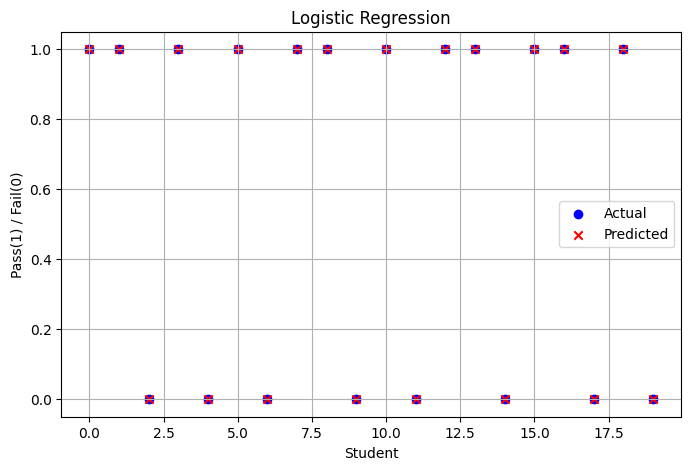

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("student_pass_fail.csv")
print(data)

# Encode categorical columns
data["Gender"] = data["Gender"].map({"Male":1, "Female":0})
data["Assignment"] = data["Assignment"].map({"Yes":1, "No":0})
data["Pass"] = data["Pass"].map({"Pass":1, "Fail":0})

# Features and Target
X = data[["Study_Hours","Attendance","Internal_Marks","Gender","Assignment"]].values
y = data["Pass"].values

# Normalize features
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Add bias term
X = np.c_[np.ones(X.shape[0]), X]

# Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Initialize weights
weights = np.zeros(X.shape[1])

# Gradient Descent
learning_rate = 0.01
epochs = 5000

for i in range(epochs):
    z = np.dot(X, weights)
    predictions = sigmoid(z)

    gradient = np.dot(X.T, (predictions - y)) / len(y)
    weights -= learning_rate * gradient

print("Weights:")
print(weights)


# Predict
probabilities = sigmoid(np.dot(X, weights))
predicted = (probabilities >= 0.5).astype(int)

# Accuracy
accuracy = np.mean(predicted == y) * 100
print("\nAccuracy: {:.2f}%".format(accuracy))

# Confusion Matrix
TP = np.sum((predicted == 1) & (y == 1))
TN = np.sum((predicted == 0) & (y == 0))
FP = np.sum((predicted == 1) & (y == 0))
FN = np.sum((predicted == 0) & (y == 1))

print("\nConfusion Matrix")
print([[TP, FP],
       [FN, TN]])

# Plot Actual vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(range(len(y)), y, color="blue", label="Actual")
plt.scatter(range(len(predicted)), predicted, color="red", marker="x", label="Predicted")

plt.title("Logistic Regression")
plt.xlabel("Student")
plt.ylabel("Pass(1) / Fail(0)")
plt.legend()
plt.grid(True)
plt.show()